"I performed end-to-end data analysis on OCD patient data.
I engineered new features like total severity score, compared multiple ML models, and optimized Random Forest using GridSearchCV.
I also analyzed feature importance to understand key drivers behind medication prediction."

In [1]:
# =========================================
# 1. IMPORT LIBRARIES
# =========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings("ignore")


In [2]:
# =========================================
# 2. LOAD DATA
# =========================================

df = pd.read_csv("OCD Patient Dataset_ Demographics & Clinical Data.csv")

print(df.shape)
print(df.head())

(1500, 17)
   Patient ID  Age  Gender Ethnicity Marital Status Education Level  \
0        1018   32  Female   African         Single    Some College   
1        2406   69    Male   African       Divorced    Some College   
2        1188   57    Male  Hispanic       Divorced  College Degree   
3        6200   27  Female  Hispanic        Married  College Degree   
4        5824   56  Female  Hispanic        Married     High School   

  OCD Diagnosis Date  Duration of Symptoms (months) Previous Diagnoses  \
0         2016-07-15                            203                MDD   
1         2017-04-28                            180                NaN   
2         2018-02-02                            173                MDD   
3         2014-08-25                            126               PTSD   
4         2022-02-20                            168               PTSD   

  Family History of OCD Obsession Type Compulsion Type  \
0                    No   Harm-related        Checking   
1

In [3]:
# =========================================
# 3. DATA CLEANING
# =========================================

# Drop irrelevant column
df.drop(columns=["OCD Diagnosis Date"], inplace=True)

# Fill missing values
df["Medications"].fillna("Unknown", inplace=True)
df["Previous Diagnoses"].fillna("None", inplace=True)

In [4]:
# =========================================
# 4. FEATURE ENGINEERING
# =========================================

# Total OCD Severity
df["Total_YBOCS"] = df["Y-BOCS Score (Obsessions)"] + df["Y-BOCS Score (Compulsions)"]

# Age group
df["Age_Group"] = pd.cut(df["Age"], bins=[0,25,40,60,100], labels=[0,1,2,3])

In [5]:
# =========================================
# 5. ENCODING
# =========================================

le = LabelEncoder()
for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])

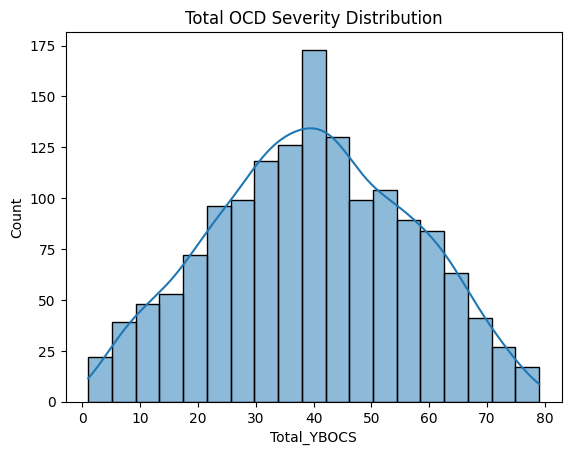

In [7]:
# =========================================
# 6. EDA (ADVANCED VISUALS)
# =========================================

# Severity distribution
plt.figure()
sns.histplot(df["Total_YBOCS"], kde=True)
plt.title("Total OCD Severity Distribution")
plt.show()

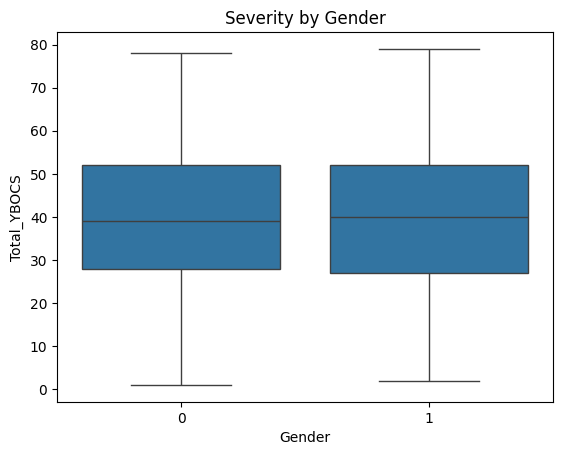

In [8]:
# Severity vs Gender
plt.figure()
sns.boxplot(x="Gender", y="Total_YBOCS", data=df)
plt.title("Severity by Gender")
plt.show()

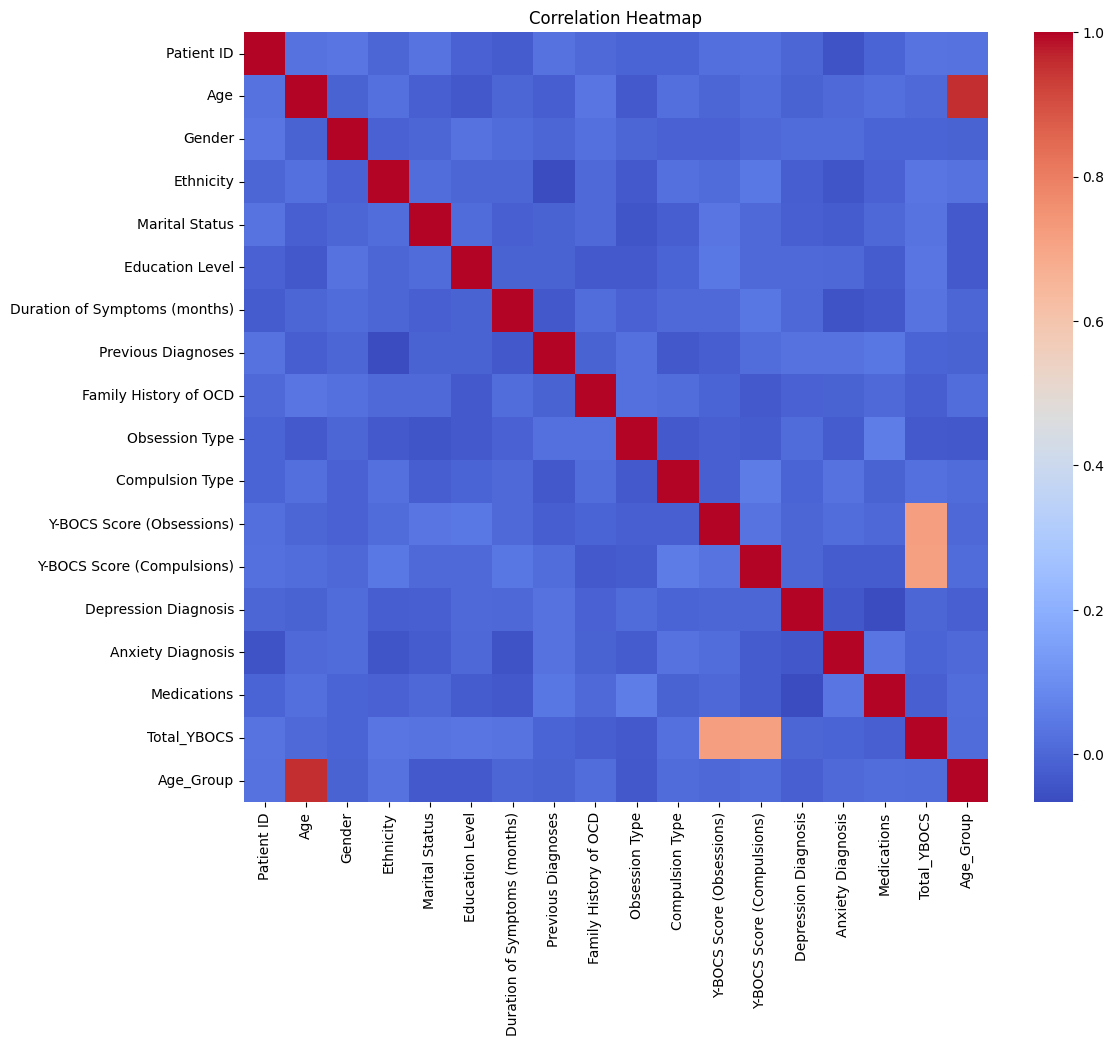

In [9]:
# Correlation heatmap
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [10]:
# =========================================
# 7. SPLIT DATA
# =========================================

X = df.drop("Medications", axis=1)
y = df["Medications"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
# =========================================
# 8. SCALING
# =========================================

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [12]:
# =========================================
# 9. MODEL COMPARISON
# =========================================

models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")

Logistic Regression Accuracy: 0.2567
Random Forest Accuracy: 0.2600
SVM Accuracy: 0.2233


In [13]:
# =========================================
# 10. BEST MODEL (RANDOM FOREST TUNING)
# =========================================

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=3)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("\nBest Parameters:", grid.best_params_)


Best Parameters: {'max_depth': 20, 'n_estimators': 200}


In [14]:
# =========================================
# 11. FINAL PREDICTION
# =========================================

y_pred = best_model.predict(X_test)

print("\nFinal Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Final Accuracy: 0.21333333333333335

Classification Report:
              precision    recall  f1-score   support

           0       0.28      0.21      0.24        96
           1       0.26      0.23      0.24        79
           2       0.04      0.03      0.04        59
           3       0.22      0.36      0.28        66

    accuracy                           0.21       300
   macro avg       0.20      0.21      0.20       300
weighted avg       0.21      0.21      0.21       300



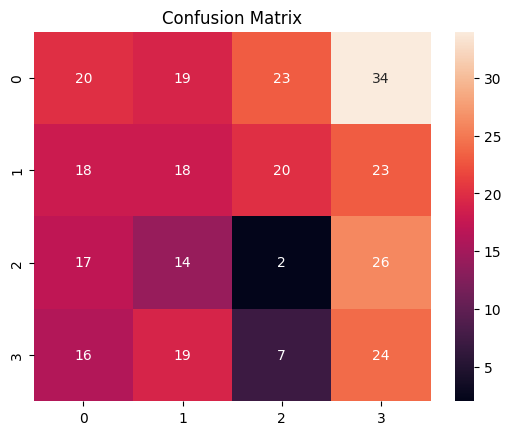

In [15]:
# =========================================
# 12. CONFUSION MATRIX
# =========================================

plt.figure()
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.show()

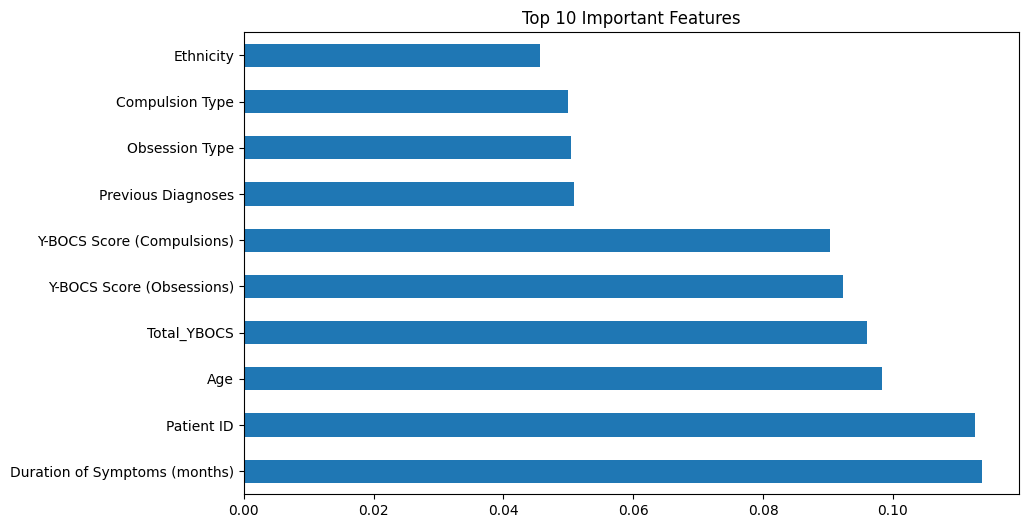

In [16]:
# =========================================
# 13. FEATURE IMPORTANCE
# =========================================

importances = best_model.feature_importances_

feat_names = X.columns

feat_imp = pd.Series(importances, index=feat_names).sort_values(ascending=False)

plt.figure(figsize=(10,6))
feat_imp.head(10).plot(kind="barh")
plt.title("Top 10 Important Features")
plt.show()